# Token Length Analysis

Analysis of solution token lengths per problem, grouped by:
1. Dataset source (augmented_math, math, augmented_gsm8k, gsm8k)
2. Difficulty level (for math source only)

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
PROBLEMS_PER_SOURCE = 30
DATA_PATH = '/storage/arik/nlp_final_project/data/openmathinstruct.jsonl'

# Load and sample data
data = []
problems_to_id = {}
id_to_problem = {}
problems_count = 0

with open(DATA_PATH, 'r') as f:
    for line in f:
        try:
            record = json.loads(line)
            record['problem'] = record['problem'].strip()
            problem = record['problem']

            if problem in problems_to_id:
                id = problems_to_id[problem]
            else:
                id = problems_count
                id_to_problem[id] = problem
                problems_to_id[problem] = id

                problems_count += 1

            record['problem_id'] = id
            data.append(record)
        except Exception as error:
            print(f'Skipped {record = }\nDue to {error = }')

df = pd.DataFrame(data)
sources = df.problem_source.unique().tolist()
n_solution_per_problem = df.groupby('problem_id').count()
print(f"Loaded {len(df)} rows")
print(f"Loaded {len(id_to_problem)} problems")
print(df['problem_source'].value_counts())

Loaded 13972791 rows
Loaded 607271 problems
problem_source
augmented_math     8938549
math               2463737
augmented_gsm8k    2111683
gsm8k               458822
Name: count, dtype: int64


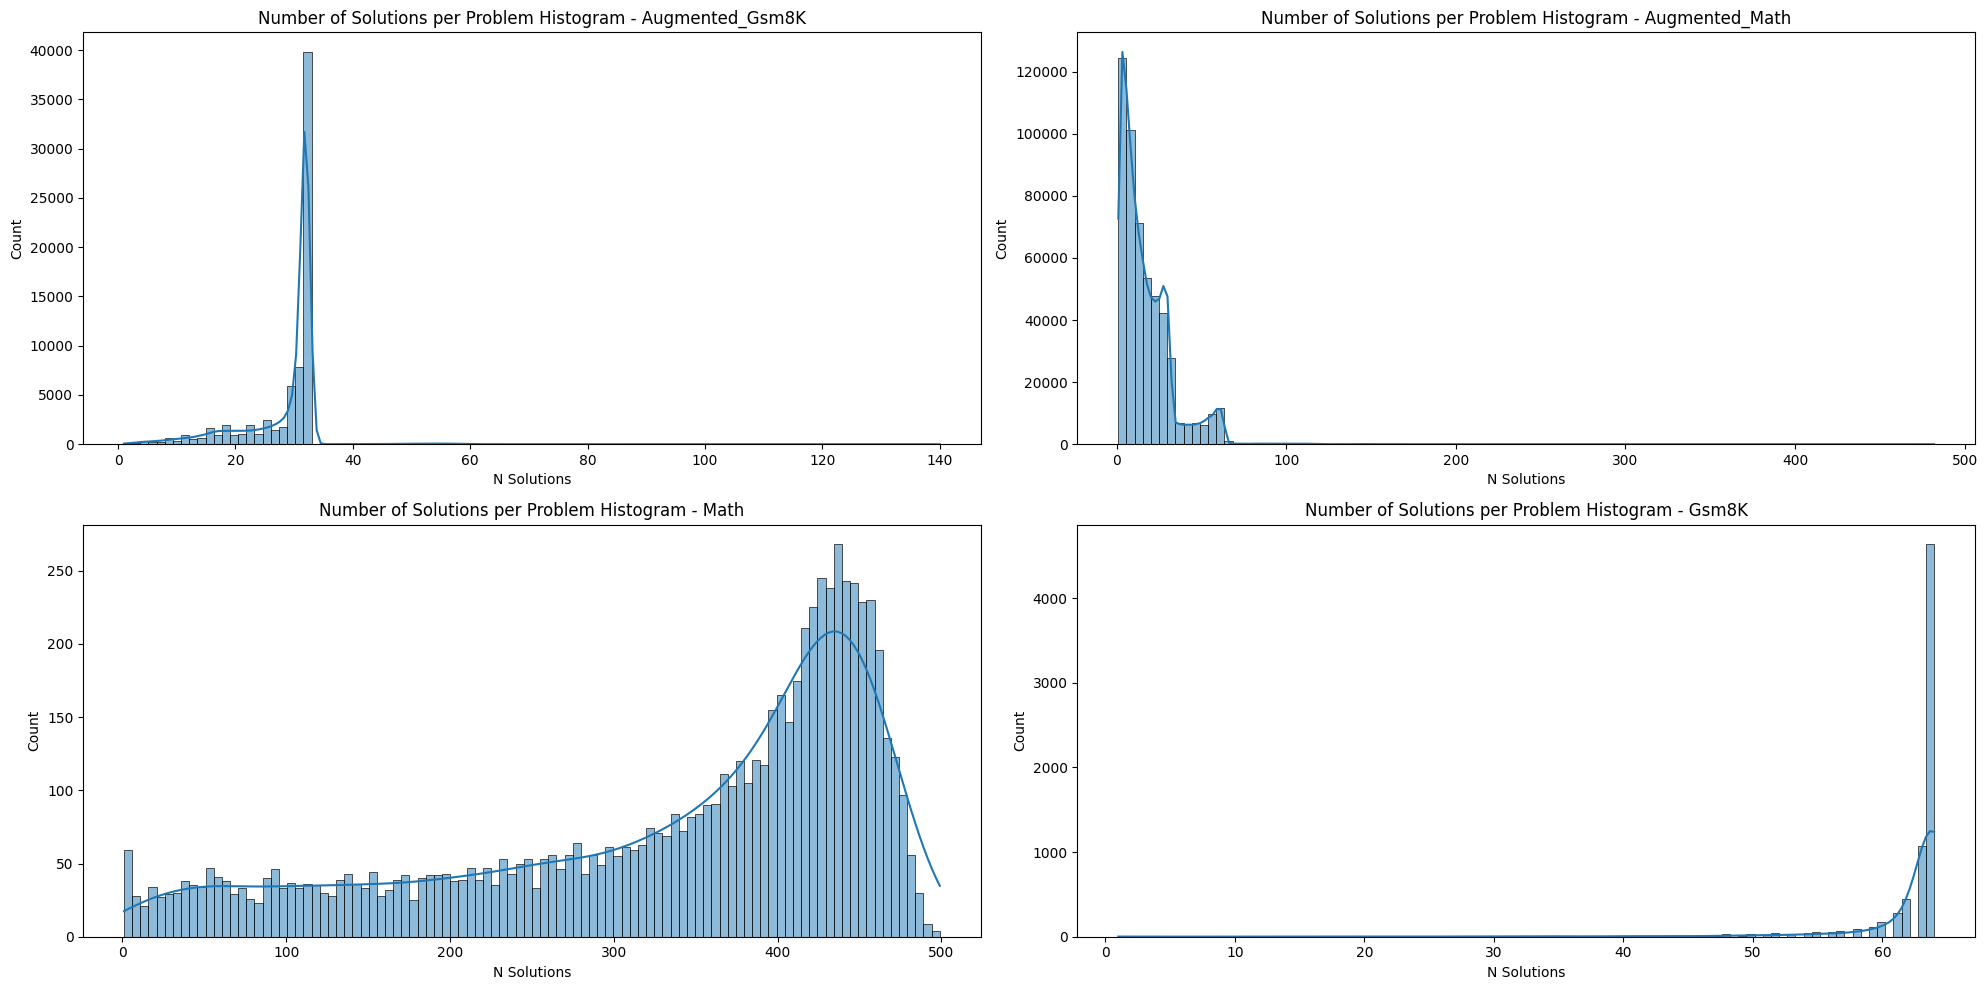

Saved: n_solutions_per_problem_hist.png


In [2]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

for i, (source) in enumerate(sources):
    row, col = i//2, i%2
    ax = axes[row, col]

    current_df = df.query(f'problem_source == "{source}"')
    n_solution = current_df.groupby('problem_id').count()

    sns.histplot(data=n_solution[n_solution.problem < 500], x='problem', bins=100, kde=True, ax=ax)
    ax.set_title(f'Number of Solutions per Problem Histogram - {source.title()}')
    # ax.set_yscale('log')
    ax.set_xlabel('N Solutions')

plt.tight_layout()
plt.savefig('/storage/arik/nlp_final_project/n_solutions_per_problem_hist.png', dpi=150)
plt.show()
print("Saved: n_solutions_per_problem_hist.png")

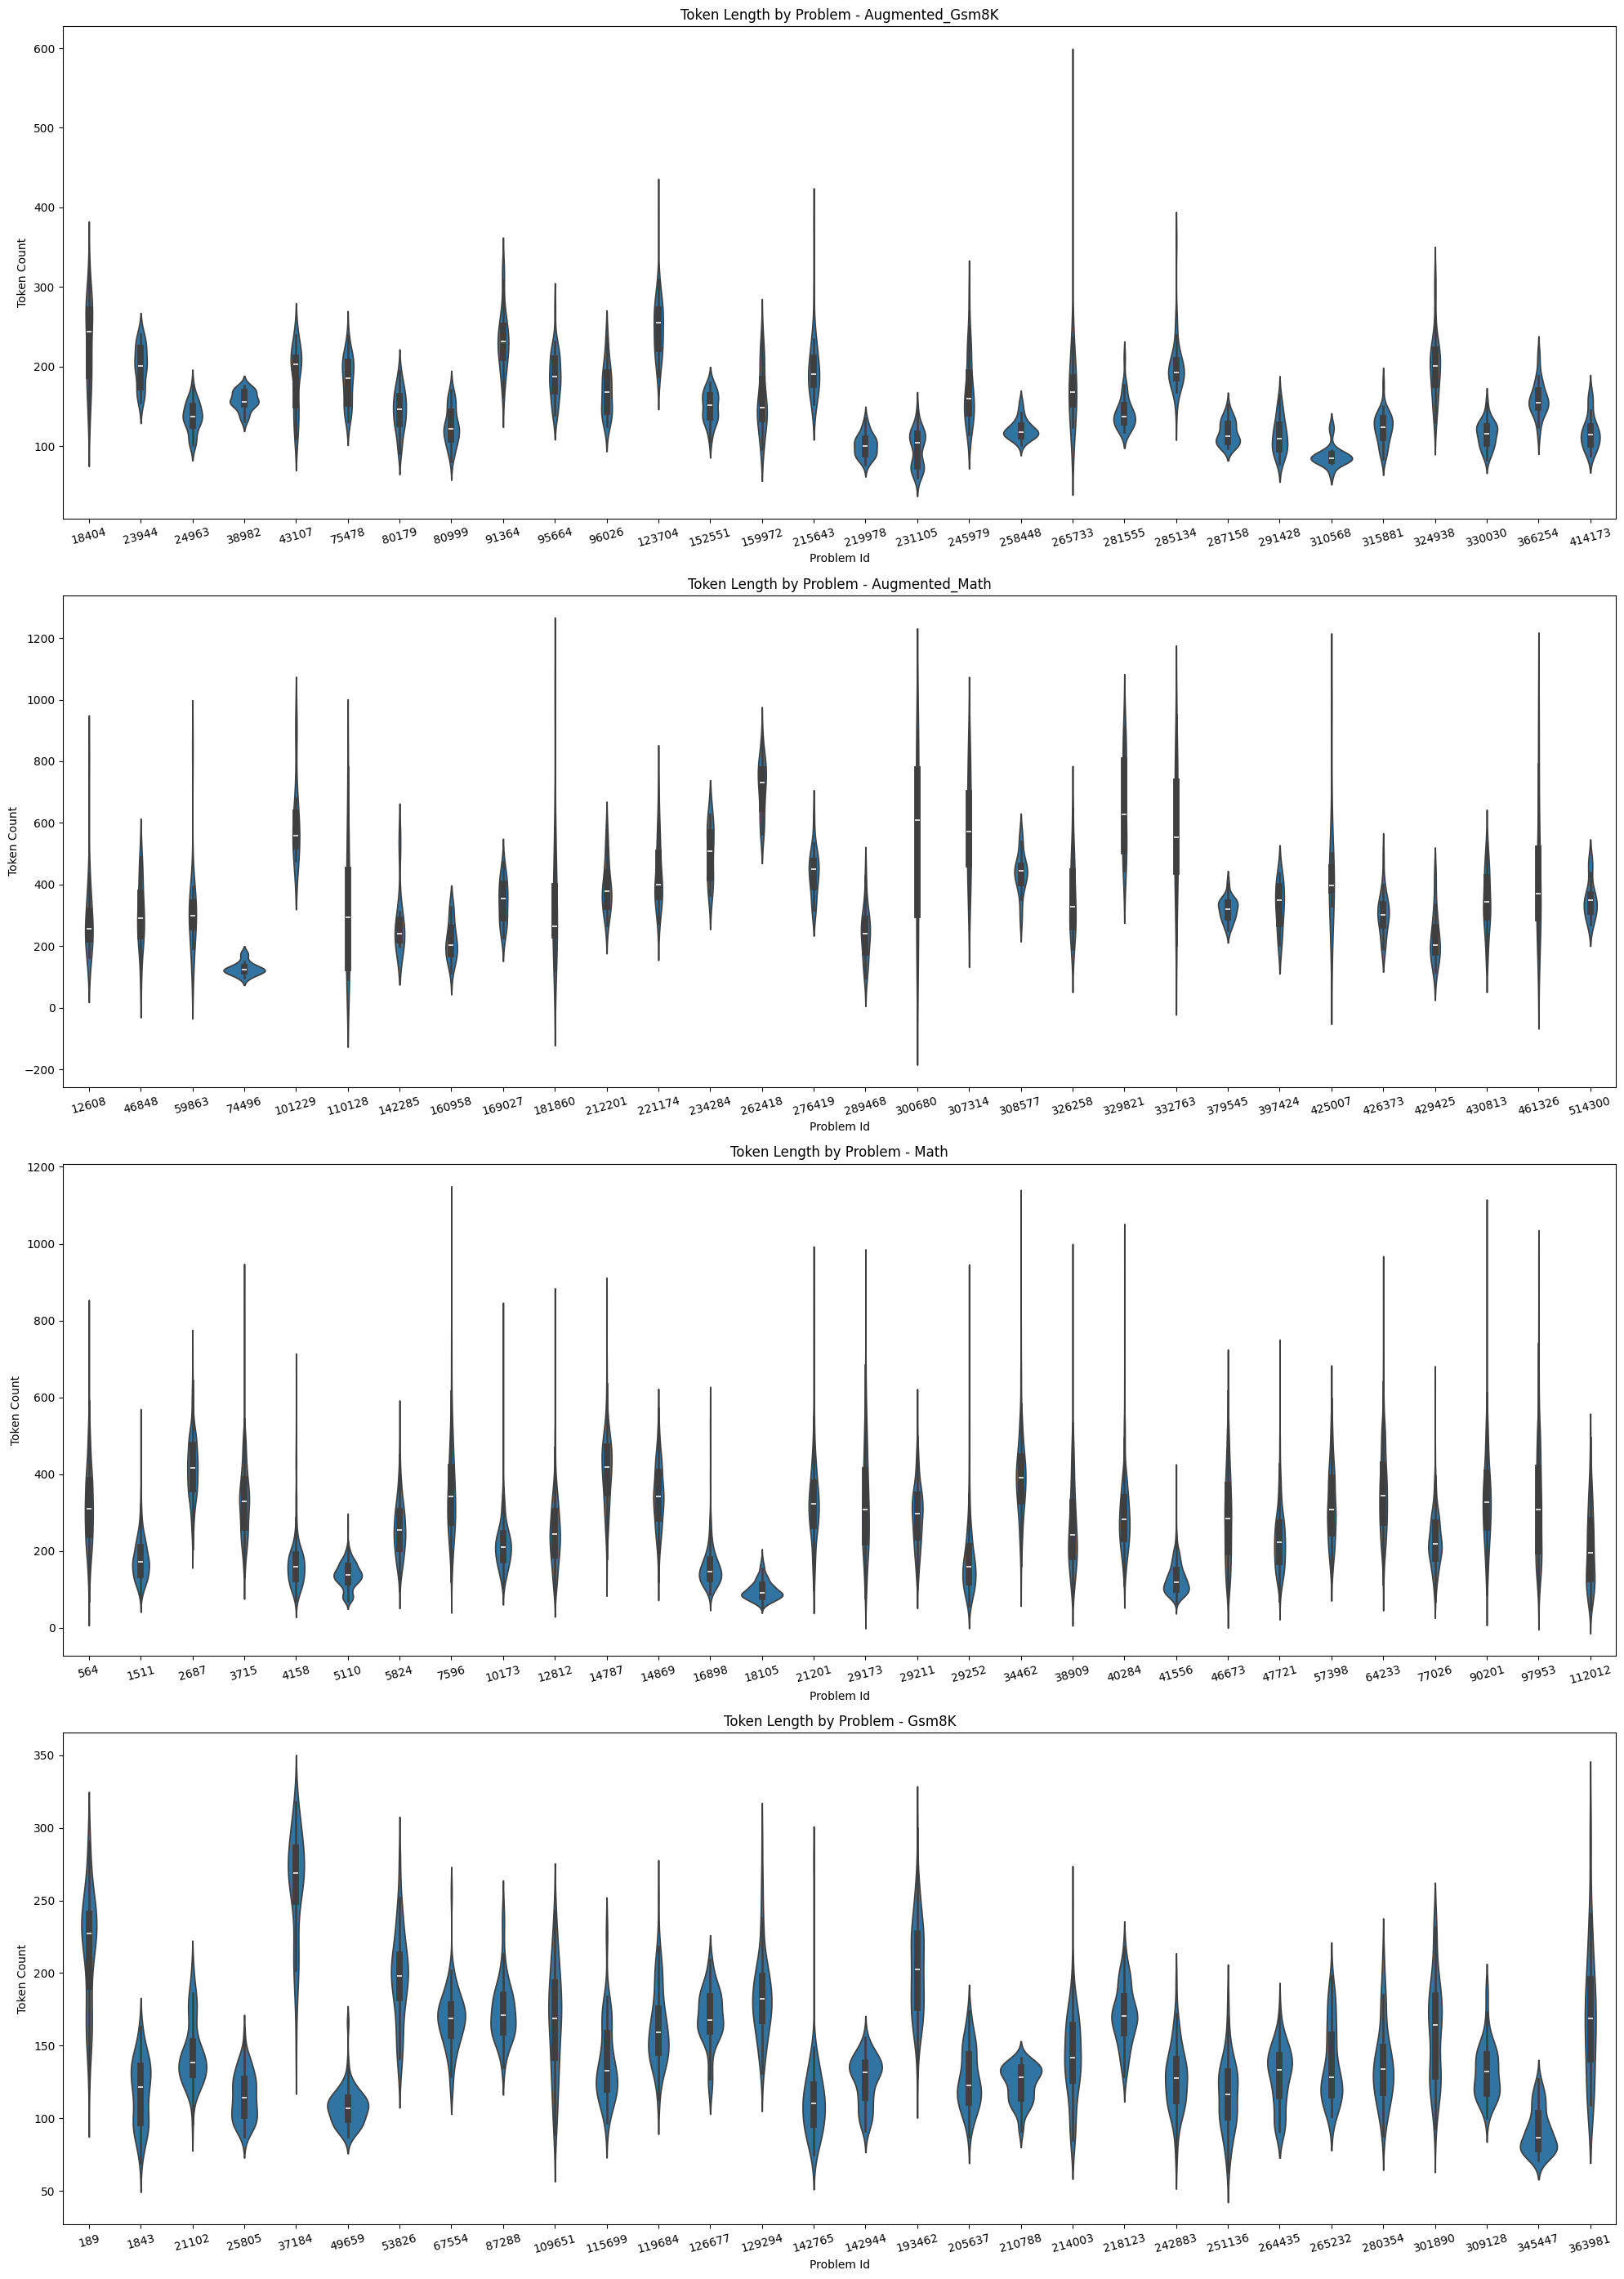

Saved: token_length_by_problem.png


In [3]:
fig, axes = plt.subplots(nrows=len(sources), figsize=(20, 7*len(sources)))

for ax, source in zip(axes, sources):
    current_df = df.query(f'problem_source == "{source}"')
    n_solutions = current_df.groupby('problem_id').problem.count().reset_index().rename(columns={'problem': 'n_sol'})
    p50 = n_solutions.n_sol.quantile(0.5)
    p75 = n_solutions.n_sol.quantile(0.75)
    sampled_problems = current_df.query(f'problem_id.isin({n_solutions[(n_solutions.n_sol >= p50) & (n_solutions.n_sol < max(p75, p50+1))].sample(PROBLEMS_PER_SOURCE).problem_id.to_list()})')

    # Violin plot
    sns.violinplot(data=sampled_problems, x='problem_id', y='teacher_token_count', ax=ax)
    ax.set_title(f'Token Length by Problem - {source.title()}')
    ax.set_xlabel('Problem Id')
    ax.set_ylabel('Token Count')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/storage/arik/nlp_final_project/token_length_by_problem.png', dpi=150)
plt.show()
print("Saved: token_length_by_problem.png")

In [4]:
# Summary statistics by source
stats_by_source = df.groupby('problem_source')['teacher_token_count'].describe()
print("=== Summary Statistics by Source ===")
print(stats_by_source.round(2))

=== Summary Statistics by Source ===
                     count    mean     std   min    25%    50%    75%     max
problem_source                                                               
augmented_gsm8k  2111683.0  166.15   73.85  41.0  118.0  152.0  197.0  1331.0
augmented_math   8938549.0  362.72  208.50  37.0  206.0  310.0  471.0  2207.0
gsm8k             458822.0  154.25   56.56  50.0  114.0  145.0  183.0  1158.0
math             2463737.0  281.32  156.85  36.0  169.0  245.0  354.0  1605.0


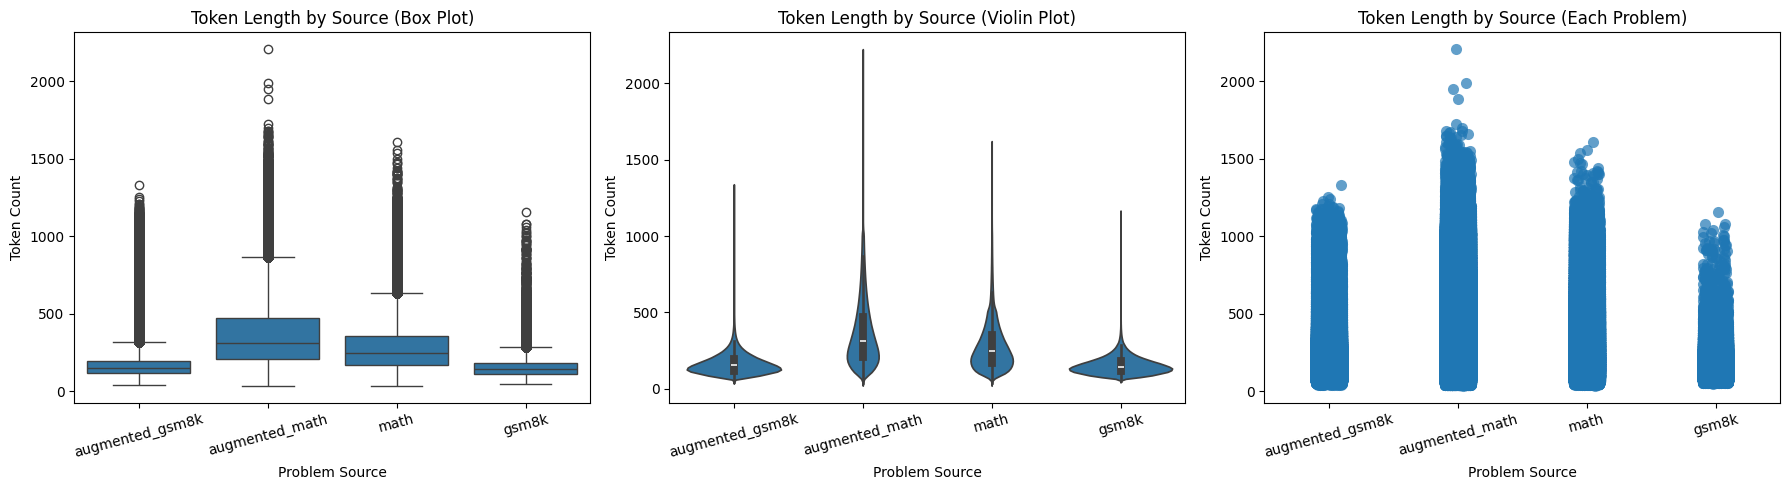

Saved: token_length_by_source.png


In [5]:
# Figure 1: Token length by source (box + violin + strip)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
sns.boxplot(data=df, x='problem_source', y='teacher_token_count', ax=axes[0])
axes[0].set_title('Token Length by Source (Box Plot)')
axes[0].set_xlabel('Problem Source')
axes[0].set_ylabel('Token Count')
axes[0].tick_params(axis='x', rotation=15)

# Violin plot
sns.violinplot(data=df, x='problem_source', y='teacher_token_count', ax=axes[1])
axes[1].set_title('Token Length by Source (Violin Plot)')
axes[1].set_xlabel('Problem Source')
axes[1].set_ylabel('Token Count')
axes[1].tick_params(axis='x', rotation=15)

# Strip plot (each problem as a point)
sns.stripplot(data=df, x='problem_source', y='teacher_token_count', ax=axes[2],
              size=8, alpha=0.7, jitter=True)
axes[2].set_title('Token Length by Source (Each Problem)')
axes[2].set_xlabel('Problem Source')
axes[2].set_ylabel('Token Count')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/storage/arik/nlp_final_project/token_length_by_source.png', dpi=150)
plt.show()
print("Saved: token_length_by_source.png")

In [6]:
# Filter to math source only
df_math = df[df['problem_source'] == 'math'].copy().sort_values('level')
print(f"\nMath problems: {len(df_math)}")
print("Level distribution:", df_math['level'].value_counts().to_dict())


Math problems: 2463737
Level distribution: {'Level 3': 594474, 'Level 4': 589937, 'Level 5': 571908, 'Level 2': 506643, 'Level 1': 199835, 'Level ?': 940}


In [7]:
# Summary statistics by level (math only)
stats_by_level = df_math.groupby('level')['teacher_token_count'].describe()
print("=== Summary Statistics by Level (Math Only) ===")
print(stats_by_level.round(2))

=== Summary Statistics by Level (Math Only) ===
            count    mean     std   min     25%    50%    75%     max
level                                                                
Level 1  199835.0  178.68   88.93  36.0  117.00  157.0  216.0  1283.0
Level 2  506643.0  221.46  117.75  38.0  140.00  193.0  271.0  1534.0
Level 3  594474.0  264.67  137.70  42.0  168.00  234.0  328.0  1605.0
Level 4  589937.0  305.07  154.27  42.0  196.00  273.0  379.0  1442.0
Level 5  571908.0  363.14  179.58  40.0  235.00  329.0  452.0  1559.0
Level ?     940.0  217.17   75.23  59.0  155.75  218.0  274.0   602.0


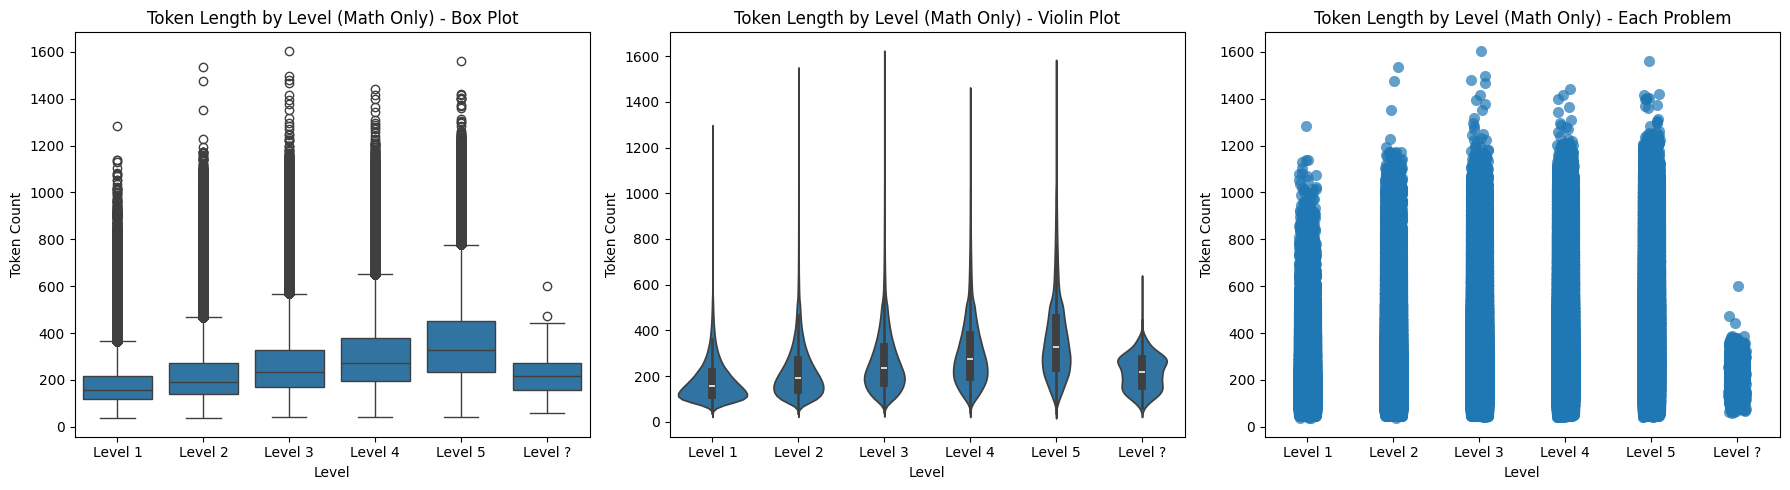

Saved: token_length_math_by_level.png


In [8]:
# Figure 2: Token length by level (math only) - box + violin + strip
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
sns.boxplot(data=df_math, x='level', y='teacher_token_count', ax=axes[0])
axes[0].set_title('Token Length by Level (Math Only) - Box Plot')
axes[0].set_xlabel('Level')
axes[0].set_ylabel('Token Count')

# Violin plot
sns.violinplot(data=df_math, x='level', y='teacher_token_count', ax=axes[1])
axes[1].set_title('Token Length by Level (Math Only) - Violin Plot')
axes[1].set_xlabel('Level')
axes[1].set_ylabel('Token Count')

# Strip plot (each problem as a point)
sns.stripplot(data=df_math, x='level', y='teacher_token_count', ax=axes[2],
              size=8, alpha=0.7, jitter=True)
axes[2].set_title('Token Length by Level (Math Only) - Each Problem')
axes[2].set_xlabel('Level')
axes[2].set_ylabel('Token Count')

plt.tight_layout()
plt.savefig('/storage/arik/nlp_final_project/token_length_math_by_level.png', dpi=150)
plt.show()
print("Saved: token_length_math_by_level.png")

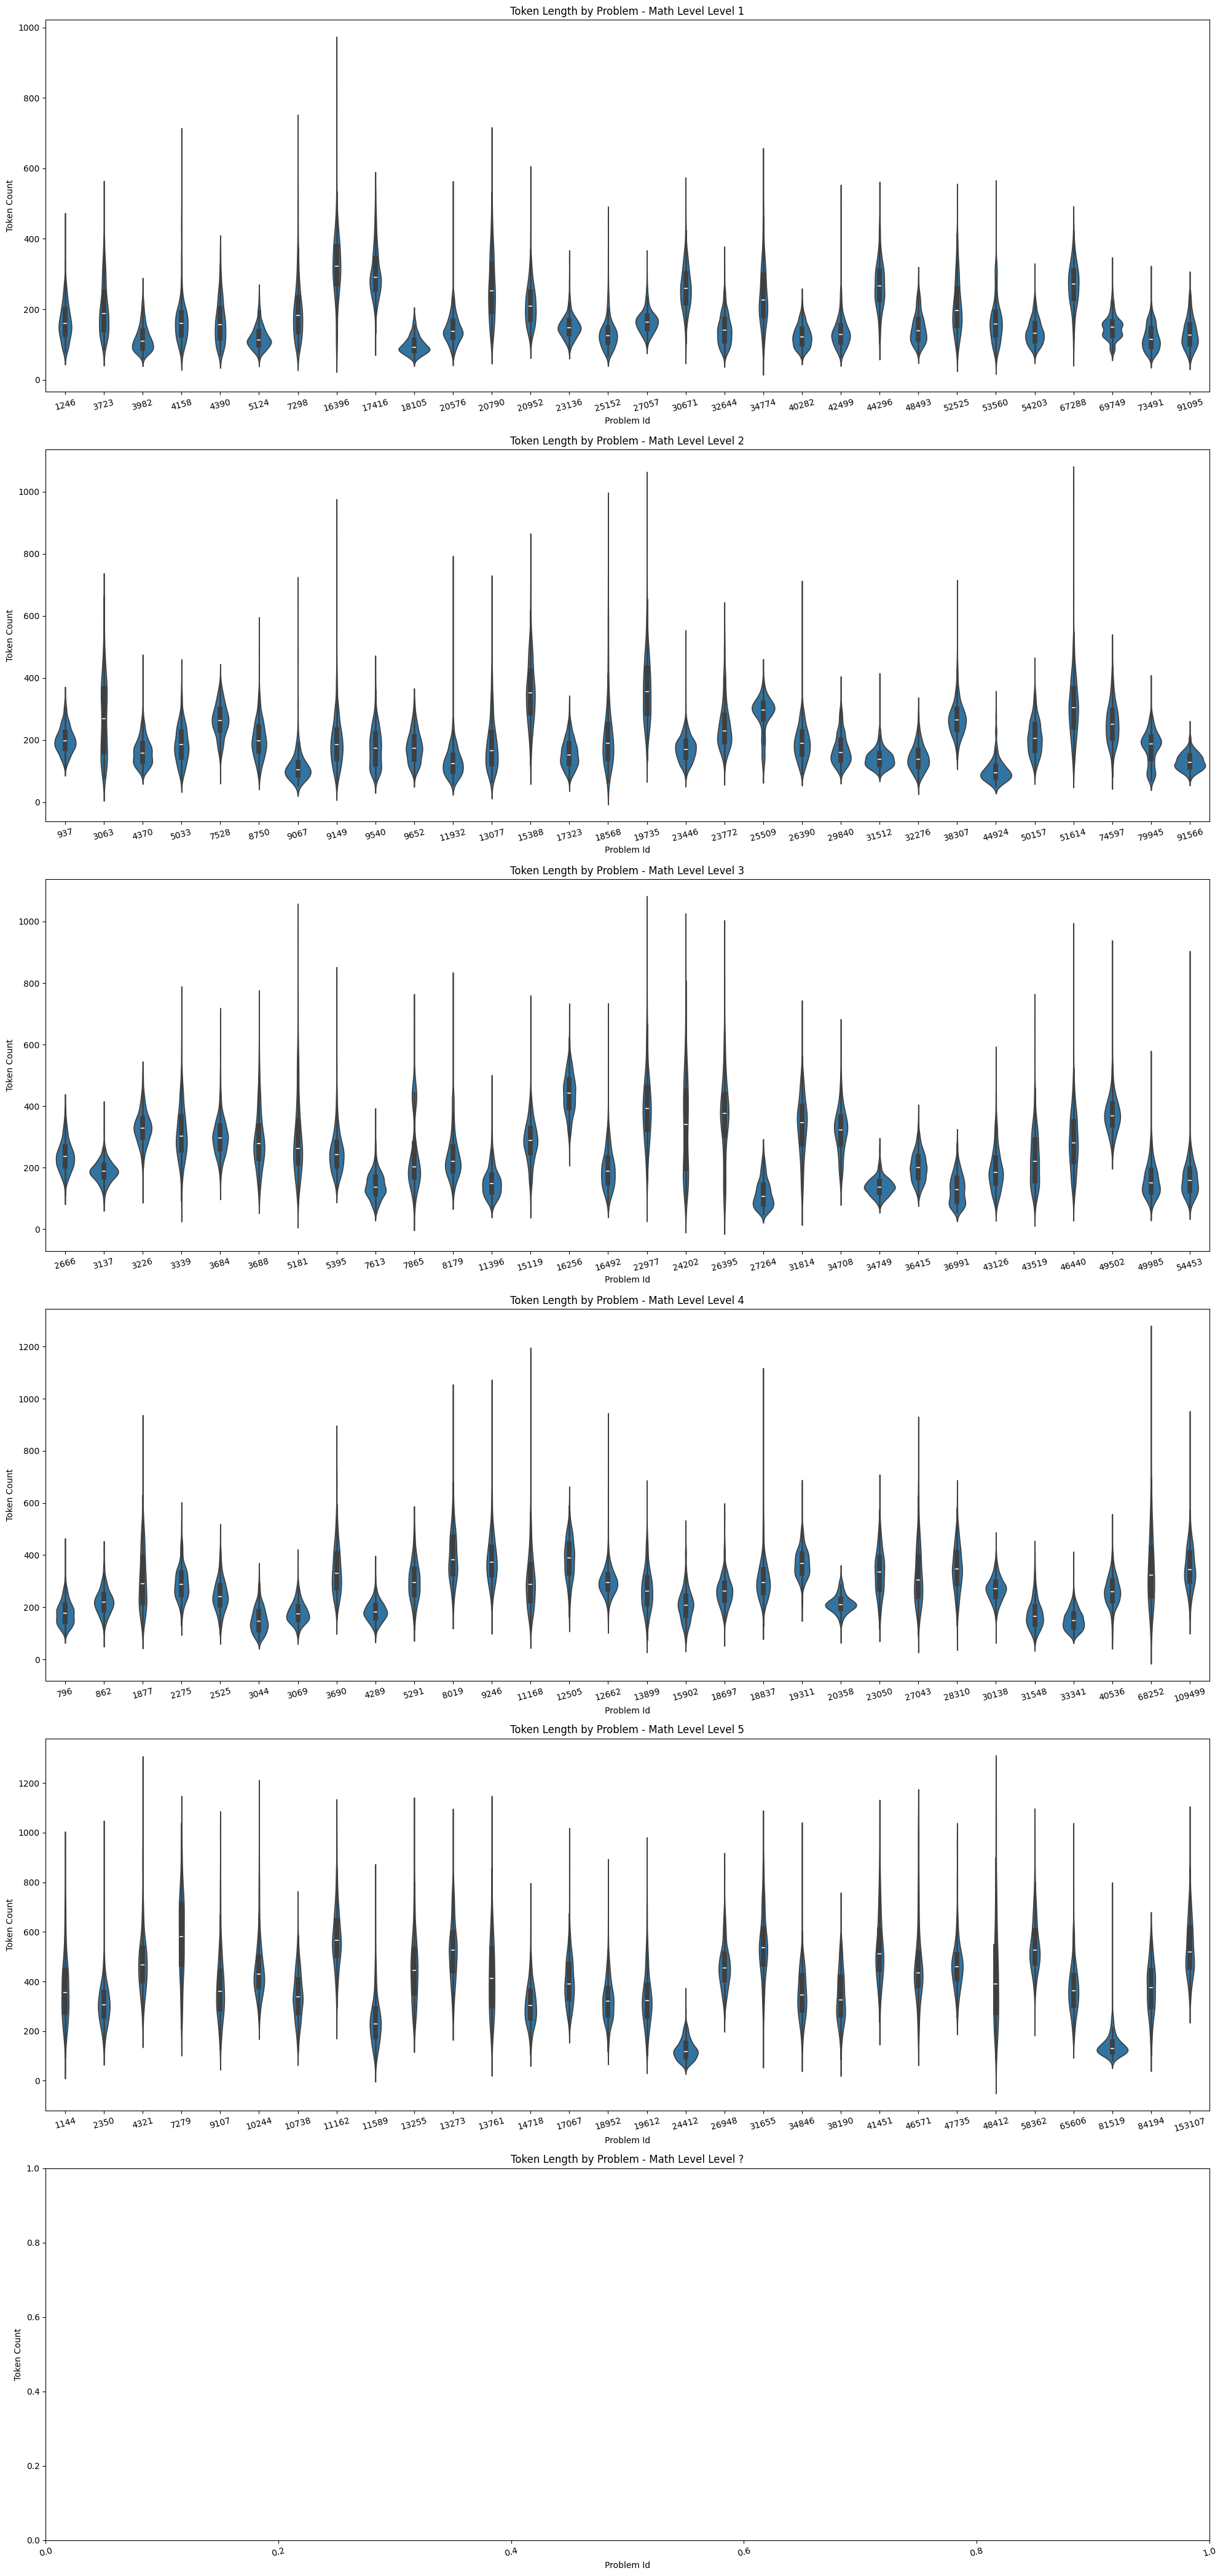

Saved: token_length_math_by_level_p50.png


In [9]:
# NEW: Figure 3 - P50 sampling by level (math only)
levels = sorted(df_math['level'].unique().tolist())
fig, axes = plt.subplots(nrows=len(levels), figsize=(20, 7*len(levels)))

for ax, level in zip(axes, levels):
    level_df = df_math.query(f'level == "{level}"')
    n_solutions = level_df.groupby('problem_id').problem.count().reset_index().rename(columns={'problem': 'n_sol'})
    p50 = n_solutions.n_sol.quantile(0.5)
    p75 = n_solutions.n_sol.quantile(0.75)

    qualifying_problems = n_solutions[(n_solutions.n_sol >= p50) & (n_solutions.n_sol < max(p75, p50+1))]

    if len(qualifying_problems) >= PROBLEMS_PER_SOURCE:
        sampled = qualifying_problems.sample(PROBLEMS_PER_SOURCE)
    else:
        sampled = qualifying_problems

    sampled_problems = level_df.query(f'problem_id.isin({sampled.problem_id.to_list()})')

    # Violin plot for each level
    sns.violinplot(data=sampled_problems, x='problem_id', y='teacher_token_count', ax=ax)
    ax.set_title(f'Token Length by Problem - Math Level {level}')
    ax.set_xlabel('Problem Id')
    ax.set_ylabel('Token Count')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/storage/arik/nlp_final_project/token_length_math_by_level_p50.png', dpi=150)
plt.show()
print("Saved: token_length_math_by_level_p50.png")

In [10]:
# Print combined summary tables with percentiles
print("\n" + "="*60)
print("COMBINED SUMMARY: Token Count by Source")
print("="*60)
def percentile_25(x): return x.quantile(0.25)
def percentile_75(x): return x.quantile(0.75)
summary_source = df.groupby('problem_source')['teacher_token_count'].agg(['count', 'mean', 'std', 'min', 'median', 'max', percentile_25, percentile_75])
summary_source.columns = ['count', 'mean', 'std', 'min', 'median', 'max', '25%', '75%']
print(summary_source.round(2))

print("\n" + "="*60)
print("COMBINED SUMMARY: Token Count by Level (Math Only)")
print("="*60)
summary_level = df_math.groupby('level')['teacher_token_count'].agg(['count', 'mean', 'std', 'min', 'median', 'max', percentile_25, percentile_75])
summary_level.columns = ['count', 'mean', 'std', 'min', 'median', 'max', '25%', '75%']
print(summary_level.round(2))


COMBINED SUMMARY: Token Count by Source


                   count    mean     std  min  median   max    25%    75%
problem_source                                                           
augmented_gsm8k  2111683  166.15   73.85   41   152.0  1331  118.0  197.0
augmented_math   8938549  362.72  208.50   37   310.0  2207  206.0  471.0
gsm8k             458822  154.25   56.56   50   145.0  1158  114.0  183.0
math             2463737  281.32  156.85   36   245.0  1605  169.0  354.0

COMBINED SUMMARY: Token Count by Level (Math Only)
          count    mean     std  min  median   max     25%    75%
level                                                            
Level 1  199835  178.68   88.93   36   157.0  1283  117.00  216.0
Level 2  506643  221.46  117.75   38   193.0  1534  140.00  271.0
Level 3  594474  264.67  137.70   42   234.0  1605  168.00  328.0
Level 4  589937  305.07  154.27   42   273.0  1442  196.00  379.0
Level 5  571908  363.14  179.58   40   329.0  1559  235.00  452.0
Level ?     940  217.17   75.23   59   218